<a href="https://colab.research.google.com/github/rajmishra-dev/python-project/blob/main/bayes_theorem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Probability with Python


# Q.1 Given that a


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bayes_theorem_student_dataset.csv to bayes_theorem_student_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv("bayes_theorem_student_dataset.csv")

df

,Student,Background,ML_Exposure
0,S1,Science,Yes
1,S2,Science,Yes
2,S3,Science,No
3,S4,Science,Yes
4,S5,Science,No
5,S6,Engineering,Yes
6,S7,Engineering,No
7,S8,Engineering,Yes
8,S9,Engineering,No
9,S10,Engineering,Yes


# Calculate the Prior Probability

P(Science) —

The probability of a student being from a Science background before considering ML exposure.

In [ ]:
science_count = (df["Background"] == "Science").sum()
total_students = len(df)

prior_science = science_count / total_students

print("Science students:", science_count)
print("Total students:", total_students)
print("P(Science):", prior_science)

Science students: 10
Total students: 20
P(Science): 0.5


# Expected Output :

Science students: 10
Total students: 20
P(Science): 0.5

# Model Evaluation Using Confusion Matrix and Classification Report

In [4]:
# Upload new dataset
from google.colab import files

uploaded = files.upload()

Saving bayes_student_project_dataset.csv to bayes_student_project_dataset.csv


Saving bayes_student_project_dataset.csv to bayes_student_project_dataset (1).csv
Dataset loaded successfully!
  Student_ID Background ML_Exposure  Coding_Level Math_Level
0       S001    Science         Yes      Beginner       High
1       S002    Science         Yes  Intermediate     Medium
2       S003    Science          No      Beginner       High
3       S004    Science         Yes      Beginner       High
4       S005    Science         Yes      Beginner     Medium

Accuracy: 67.50%


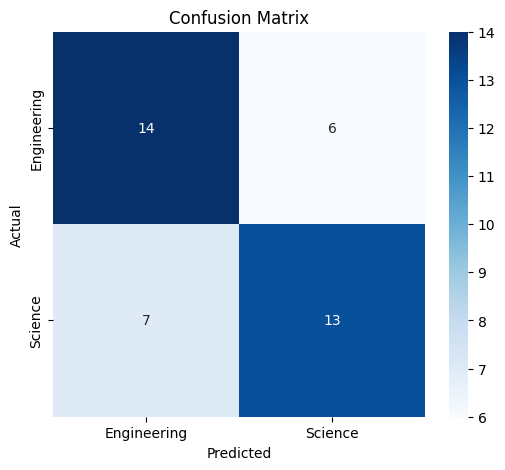


Classification Report:

              precision    recall  f1-score   support

 Engineering       0.67      0.70      0.68        20
     Science       0.68      0.65      0.67        20

    accuracy                           0.68        40
   macro avg       0.68      0.68      0.67        40
weighted avg       0.68      0.68      0.67        40



In [7]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load uploaded dataset
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print(df.head())

# Features and target
X = df[["ML_Exposure", "Coding_Level", "Math_Level"]]
y = df["Background"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",
         OneHotEncoder(handle_unknown="ignore"),
         ["ML_Exposure", "Coding_Level", "Math_Level"])
    ]
)

# Create model
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", MultinomialNB())
])

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy * 100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Engineering", "Science"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Engineering", "Science"],
    yticklabels=["Engineering", "Science"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=["Engineering", "Science"],
        target_names=["Engineering", "Science"]
    )
)


Day : 05/09/2026 today's work:

# Q. Bayes Theorem — Medical Test

A disease affects 1% of the population. A medical test is:

95% positive when a person actually has the disease.
5% positive when a person does not have the disease.

Question: If a randomly selected person tests positive, what is the probability that the person actually has the disease?

The Given Question :

Bayes Theorem + Python dono se solve karte hain.

Question

Given:

$$ P(D)=0.01 $$ $$ P(+|D)=0.95 $$ $$ P(+|\neg D)=0.05 $$

Find:

$$ P(D|+) $$
Step 1 — Bayes Formula
$$ P(D|+)=\frac{P(+|D)P(D)}{P(+)} $$

Where:

P(+)=P(+∣D)P(D)+P(+∣¬D)P(¬D)

In [3]:
# Given probabilities

P_D = 0.01
P_positive_given_D = 0.95
P_positive_given_not_D = 0.05

# Probability of not having the disease
P_not_D = 1 - P_D

# Total probability of a positive test
P_positive = (
    P_positive_given_D * P_D
    + P_positive_given_not_D * P_not_D
)

# Bayes Theorem
P_D_given_positive = (
    P_positive_given_D * P_D
    / P_positive
)

print("P(Disease | Positive):", P_D_given_positive)
print("Percentage:", P_D_given_positive * 100, "%")

P(Disease | Positive): 0.16101694915254236
Percentage: 16.101694915254235 %
